In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install keras


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import california_housing
cal_hdf = california_housing.load_data()
type(cal_hdf)


743530/743530 ━━━━━━━━━━━━━━━━━━━━ 2s 2us/step


tuple

In [4]:
len(cal_hdf)

2

In [5]:
(x_train, y_train), (x_test, y_test) = cal_hdf

In [6]:
x_train.shape

(16512, 8)

In [7]:
x_train[:1]

array([[-118.27  ,   34.09  ,   52.    , 2327.    ,  555.    , 1048.    ,
         491.    ,    3.7847]], dtype=float32)

In [8]:
y_train[:1]

array([252300.], dtype=float32)

In [9]:
x_test.shape

(4128, 8)

In [10]:
y_test.shape

(4128,)

In [12]:
#scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled[:1]

array([[ 0.6457757 , -0.720931  ,  1.853275  , -0.14375813,  0.0361992 ,
        -0.3331862 , -0.02698462, -0.04505225]], dtype=float32)

In [19]:
#creating neural network architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(128, activation= "relu")) 
model.add(Dense(1)) #Output layer


In [20]:
#Compiling the NN
model.compile(loss = 'mean_absolute_error', optimizer = 'sgd', metrics = ['mae'])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Training the NN model
history = model.fit(x_train_scaled,y_train, epochs = 60, validation_split = 0.2)

Epoch 1/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 206396.8438 - mae: 206396.8438 - val_loss: 206387.1406 - val_mae: 206387.1406
Epoch 2/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 134459.8750 - mae: 134459.8750 - val_loss: 54472.4531 - val_mae: 54472.4531
Epoch 3/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51801.9414 - mae: 51801.9414 - val_loss: 48915.6484 - val_mae: 48915.6484
Epoch 4/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49334.2305 - mae: 49334.2305 - val_loss: 48066.5430 - val_mae: 48066.5430
Epoch 5/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 48423.3906 - mae: 48423.3906 - val_loss: 47873.9492 - val_mae: 47873.9492
Epoch 6/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47713.5039 - mae: 47713.5039 - val_loss: 46857.4453 - val_mae: 46857.4453
Epoch 7/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47060.2148 - mae: 47060.2148 - val_loss: 46311.3008 - val_mae: 46311.3008
Epoch 8/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,283 (5.02 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

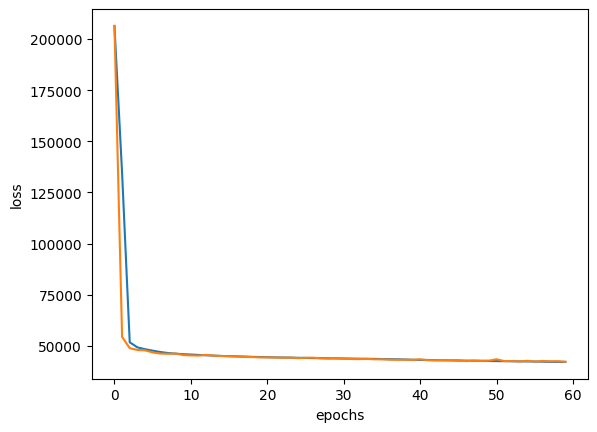

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [25]:
#Evaluate the model
model.evaluate(x_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - loss: 43582.3633 - mae: 43582.3633


[43582.36328125, 43582.36328125]

In [26]:
x_new = x_test_scaled[:3]
prediction = model.predict(x_new)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[214350.72]
 [297407.25]
 [161519.5 ]]


In [27]:
y_test[:3]

array([397900., 227900., 172100.], dtype=float32)

In [28]:
model.save('cal_housing_price.keras')

In [31]:
#loading the model
from tensorflow.keras.models import load_model
model1 = load_model('cal_housing_price.keras')

In [32]:
# output with this model taking input from user
import numpy as np
input_data = np.array([[8.3252, 41.0, 6.9841, 1.0238095238095237, 322.0, 2.5555555555555554, 37.88, -122.23]])
input_data_scaled = scaler.transform(input_data)
input_data_scaled
model.predict(input_data_scaled)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[-448643.6]], dtype=float32)